# Yield Curve PCA

Fits PCA factors (level, slope, curvature) to historical Treasury par yield curve
changes, reading directly from Postgres via DuckDB's `postgres` extension --
no separate fetch/parse step, the history already lives in the canonical store
populated by [DailyTreasuryParYieldCurve.ipynb](../YieldCurve/DailyTreasuryParYieldCurve.ipynb).

See [docs/refactor-plan.md](../docs/refactor-plan.md) section 8 for the design.

## Load history via DuckDB -> Postgres

In [1]:
from fred_lx.storage.duckdb_store import attach_postgres
from fred_lx.analysis.pca import fit_yield_pca
from fred_lx.viz.pca import plot_components, plot_explained_variance, plot_scores

con = attach_postgres()
history = con.sql("""
    SELECT curve_date AS date, maturity_years, par_yield
    FROM pg.treasury_par_yields
    WHERE source = 'treasury_xml'
""").df()

print(f"{len(history):,} rows, {history['date'].nunique()} dates, "
      f"{history['date'].min()} -> {history['date'].max()}")
history.head()

4,758 rows, 366 dates, 2025-01-02 00:00:00 -> 2026-06-18 00:00:00


,date,maturity_years,par_yield
0,2025-01-02,0.083333,4.45
1,2025-01-03,0.083333,4.44
2,2025-01-06,0.083333,4.43
3,2025-01-07,0.083333,4.42
4,2025-01-08,0.083333,4.41


## Fit PCA on day-over-day yield changes

In [2]:
result = fit_yield_pca(history, n_components=3)

for i, ratio in enumerate(result.explained_variance_ratio, start=1):
    print(f"PC{i}: {ratio:.1%} of variance")

PC1: 79.3% of variance
PC2: 10.3% of variance
PC3: 3.4% of variance


## Component shapes (level / slope / curvature)

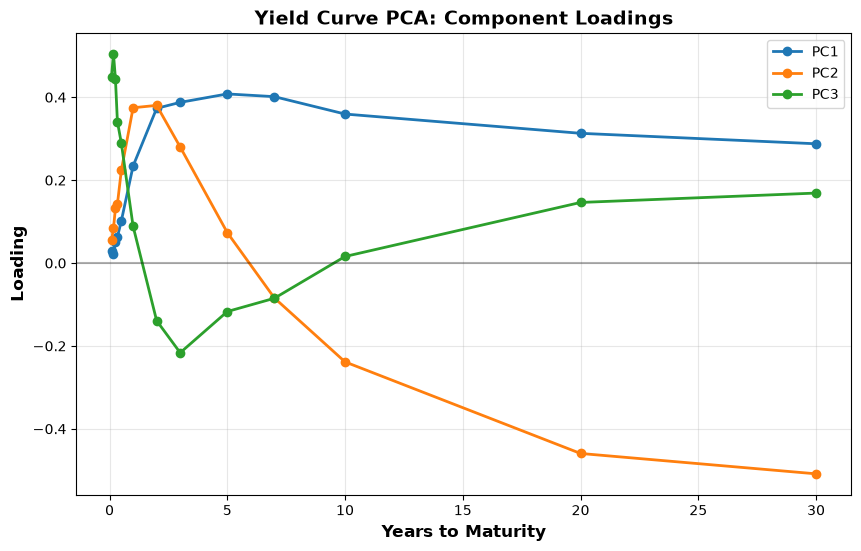

In [3]:
plot_components(result);

## Explained variance

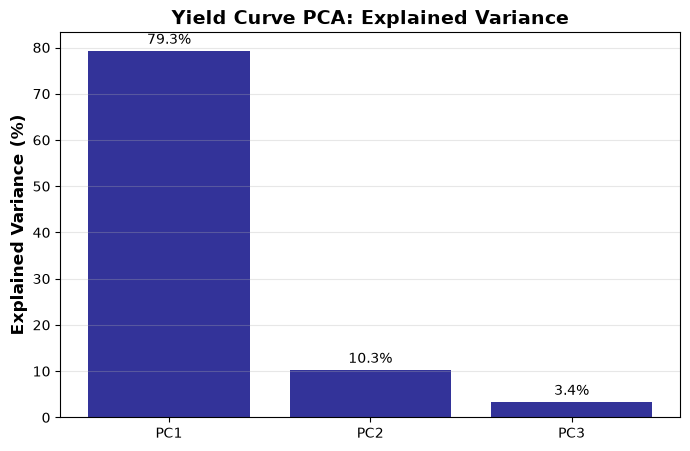

In [4]:
plot_explained_variance(result);

## Factor scores over time

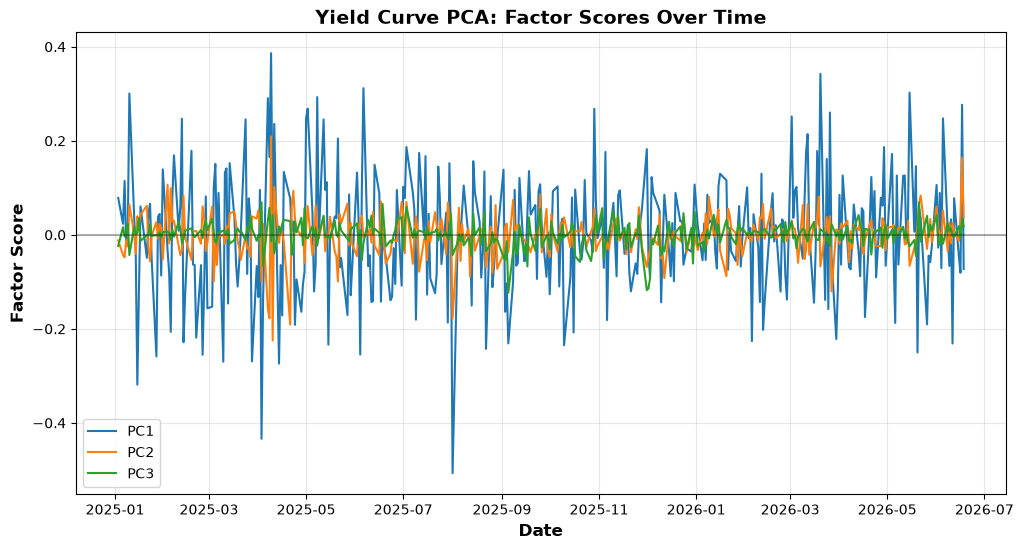

In [5]:
plot_scores(result);